In [ ]:
from google.colab import drive
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import random
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
import shutil
from sklearn.model_selection import train_test_split

# Define paths
base_path = "/content/drive/My Drive/Colab Notebooks/anterior_eye"
train_path = os.path.join(base_path, "train")
test_path = os.path.join(base_path, "test")

# Function to count images in a folder
def count_images(folder_path):
    count = {}
    for category in os.listdir(folder_path):
        category_path = os.path.join(folder_path, category)
        if os.path.isdir(category_path):
            count[category] = len(os.listdir(category_path))
    return count

# Get image counts
train_counts = count_images(train_path)
test_counts = count_images(test_path)

# Print results
print("Train set image counts:", train_counts)
print("Test set image counts:", test_counts)




Train set image counts: {'Normal': 2383, 'cataract': 2355}
Test set image counts: {'cataract': 589, 'Normal': 643}


In [ ]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input

# Load Pre-trained ResNet50 model (without the classification head)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Define dataset path (training folder)
dataset_path = "/content/drive/MyDrive/Colab Notebooks/anterior_eye/train"

# Function to extract features
def extract_features(directory):
    data = []
    labels = []

    for category in os.listdir(directory):  # Cataract, Normal
        category_path = os.path.join(directory, category)
        if os.path.isdir(category_path):
            for img_name in os.listdir(category_path):
                img_path = os.path.join(category_path, img_name)

                # Load and preprocess image
                img = load_img(img_path, target_size=(224, 224))
                img_array = img_to_array(img)
                img_array = np.expand_dims(img_array, axis=0)
                img_array = preprocess_input(img_array)  # Normalize for ResNet50

                # Extract features
                features = base_model.predict(img_array)
                features = features.flatten()  # Flatten the feature map

                # Append to data
                data.append(features)
                labels.append(1 if category.lower() == "cataract" else 0)

    return np.array(data), np.array(labels)

# Extract features
X, y = extract_features(dataset_path)
print(f"Feature shape for last image: {X[-1].shape}")

# Convert to DataFrame
df = pd.DataFrame(X)
df['label'] = y

# Save CSV
csv_path = "/content/drive/MyDrive/Colab Notebooks/anterior_eye/re50_sli.csv"
df.to_csv(csv_path, index=False)

print(f"✅ CSV saved at: {csv_path}")
print(df.head())
print("Unique train labels:", np.unique(y))


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


In [ ]:
import pandas as pd

# Load the extracted feature dataset
csv_path = "/content/drive/MyDrive/Colab Notebooks/anterior_eye/re50_sli.csv"  # Change if needed
df = pd.read_csv(csv_path, usecols=['label'])

# Check unique labels
unique_labels = df['label'].unique()

# Print results
print(f"✅ Unique labels in dataset: {unique_labels}")

# Count occurrences of each category
label_counts = df['label'].value_counts()
print("\n📊 Label distribution:")
print(label_counts)


✅ Unique labels in dataset: [0 1]

📊 Label distribution:
label
0    2371
1    2355
Name: count, dtype: int64


In [ ]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input

# Load Pre-trained ResNet50 model (without the classification head)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Define dataset path (training folder)
dataset_path = "/content/drive/MyDrive/Colab Notebooks/anterior_eye/test"

# Function to extract features
def extract_features(directory):
    data = []
    labels = []

    for category in os.listdir(directory):  # Cataract, Normal
        category_path = os.path.join(directory, category)
        if os.path.isdir(category_path):
            for img_name in os.listdir(category_path):
                img_path = os.path.join(category_path, img_name)

                # Load and preprocess image
                img = load_img(img_path, target_size=(224, 224))
                img_array = img_to_array(img)
                img_array = np.expand_dims(img_array, axis=0)
                img_array = preprocess_input(img_array)  # Normalize for ResNet50

                # Extract features
                features = base_model.predict(img_array)
                features = features.flatten()  # Flatten the feature map

                # Append to data
                data.append(features)
                labels.append(1 if category.lower() == "cataract" else 0)

    return np.array(data), np.array(labels)

# Extract features
X, y = extract_features(dataset_path)
print(f"Feature shape for last image: {X[-1].shape}")

# Convert to DataFrame
df = pd.DataFrame(X)
df['label'] = y

# Save CSV
csv_path = "/content/drive/MyDrive/Colab Notebooks/anterior_eye/re50_sli_test.csv"
df.to_csv(csv_path, index=False)

print(f"✅ CSV saved at: {csv_path}")
print(df.head())
print("Unique train labels:", np.unique(y))


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 555ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
1/1 ━━━━━━━━━━━━

In [ ]:
import pandas as pd

train_path = "//content/drive/MyDrive/Colab Notebooks/anterior_eye/ant_eye/re50_sli.csv"
test_path = "/content/drive/MyDrive/Colab Notebooks/anterior_eye/re50_sli_test.csv"
train_df = pd.read_csv(train_path)  # Load train data
test_df = pd.read_csv(test_path)
# Read CSV files
train_df['label'] = train_df['label'].map({'cataract': 1, 'normal': 0})
test_df['label'] = test_df['label'].map({'cataract': 1, 'normal': 0})

# ✅ 2. Prepare Data
X_train = train_df.drop(columns=["label"]).values  # Drop label column, keep features
#y_train = train_df["label"].astype(int).values  # Convert labels to integers

X_test = test_df.drop(columns=["label"]).values
# ✅ Convert label column to integers (if categorical)
#y_test = test_df["label"].astype(int).values

'''X_train, y_train = train_df.iloc[:, :-1].values, train_df.iloc[:, -1].values
X_test, y_test = test_df.iloc[:, :-1].values, test_df.iloc[:, -1].values
# Check unique labels
unique_labels = df['label'].unique()'''

# Print results
print(f"✅ Unique labels in dataset: {unique_labels}")

# Count occurrences of each category
label_counts = df['label'].value_counts()
print("\n📊 Label distribution:")
print(label_counts)
print("Original Shape :", X_train.shape, X_test.shape)


ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

MODEL TRAINING MLP

]

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping


train_path = "/content/drive/MyDrive/Colab Notebooks/anterior_eye/ant_eye/re50_sli.csv"
test_path = "/content/drive/MyDrive/Colab Notebooks/anterior_eye/ant_eye/re50_sli_test.csv"
train_df = pd.read_csv(train_path)  # Load train data
test_df = pd.read_csv(test_path)
# Read CSV files
train_df['label'] = train_df['label'].map({'cataract': 1, 'normal': 0})
test_df['label'] = test_df['label'].map({'cataract': 1, 'normal': 0})
'''
# ✅ 2. Prepare Data
X_train = train_df.drop(columns=["label"]).values  # Drop label column, keep features
y_train = train_df["label"].astype(int).values  # Convert labels to integers

X_test = test_df.drop(columns=["label"]).values
# ✅ Convert label column to integers (if categorical)
y_test = test_df["label"].astype(int).values'''

X_train, y_train = train_df.iloc[:, :-1].values, train_df.iloc[:, -1].values
X_test, y_test = test_df.iloc[:, :-1].values, test_df.iloc[:, -1].values
# Normalize Data
X_train = X_train / np.max(X_train)
X_test = X_test / np.max(X_test)

# ✅ 3. Define MLP Model
model = Sequential([
    Dense(64, activation="relu", kernel_regularizer=l2(0.005), input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(32, activation="relu", kernel_regularizer=l2(0.005)),
    Dropout(0.3),
    Dense(1, activation="sigmoid")  # Binary classification
])

# ✅ Define Optimizer with Learning Rate
optimizer = Adam(learning_rate=0.0001)

# ✅ 4. Compile Model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ✅ 5. Train Model
early_stopping = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

# ✅ Train Model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,   # ✅ Limit epochs to 10
    batch_size=64,  # ✅ Ensure reasonable batch size
    callbacks=[early_stopping],
    verbose=1)
# ✅ 6. Save Model for Future Use
model.save("/content/drive/MyDrive/Colab Notebooks/anterior_eye/ant_eye/mlp_rez_model.h5")

# ✅ 7. Plot Accuracy and Loss
plt.figure(figsize=(12, 5))

# 🔹 Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Test Accuracy', marker='s')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Train vs. Test Accuracy')
plt.legend()

# 🔹 Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Test Loss', marker='s')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train vs. Test Loss')
plt.legend()

plt.show()


In [ ]:
import tensorflow as tf
tf.keras.backend.clear_session()


In [ ]:
import gc
gc.collect()


3

In [ ]:
!ls -lh "/content/drive/MyDrive/Colab Notebooks/anterior_eye/ant_eye/re50_sli.csv"

-rw------- 1 root root 2.4G Apr  7 00:00 '/content/drive/MyDrive/Colab Notebooks/anterior_eye/ant_eye/re50_sli.csv'


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping


train_path = "/content/drive/MyDrive/Colab Notebooks/anterior_eye/ant_eye/re50_sli.csv"
test_path = "/content/drive/MyDrive/Colab Notebooks/anterior_eye/ant_eye/re50_sli_test.csv"
# Specify the 'engine' parameter as 'python'
train_df = pd.read_csv(train_path, engine='python')  # Load train data
test_df = pd.read_csv(test_path, engine='python')
# Read CSV files
train_df['label'] = train_df['label'].map({'cataract': 1, 'normal': 0})
test_df['label'] = test_df['label'].map({'cataract': 1, 'normal': 0})
'''
# ✅ 2. Prepare Data
X_train = train_df.drop(columns=["label"]).values  # Drop label column, keep features
y_train = train_df["label"].astype(int).values  # Convert labels to integers

X_test = test_df.drop(columns=["label"]).values
# ✅ Convert label column to integers (if categorical)
y_test = test_df["label"].astype(int).values'''

X_train, y_train = train_df.iloc[:, :-1].values, train_df.iloc[:, -1].values
X_test, y_test = test_df.iloc[:, :-1].values, test_df.iloc[:, -1].values
# Normalize Data
X_train = X_train / np.max(X_train)
X_test = X_test / np.max(X_test)

# ✅ 3. Define MLP Model
model = Sequential([
    Dense(64, activation="relu", kernel_regularizer=l2(0.005), input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(32, activation="relu", kernel_regularizer=l2(0.005)),
    Dropout(0.3),
    Dense(1, activation="sigmoid")  # Binary classification
])

# ✅ Define Optimizer with Learning Rate
optimizer = Adam(learning_rate=0.0001)

# ✅ 4. Compile Model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ✅ 5. Train Model
early_stopping = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

# ✅ Train Model
history_vgg = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,   # ✅ Limit epochs to 10
    batch_size=64,  # ✅ Ensure reasonable batch size
    callbacks=[early_stopping],
    verbose=1)
# ✅ 6. Save Model for Future Use
model.save("/content/drive/MyDrive/Colab Notebooks/anterior_eye/mlp_rez_model.h5")

# ✅ 7. Plot Accuracy and Loss
plt.figure(figsize=(12, 5))

# 🔹 Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history_vgg.history['accuracy'], label='Train Accuracy', marker='o') # Changed to history_vgg
plt.plot(history_vgg.history['val_accuracy'], label='Test Accuracy', marker='s') # Changed to history_vgg
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Train vs. Test Accuracy')
plt.legend()

# 🔹 Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history_vgg.history['loss'], label='Train Loss', marker='o') # Changed to history_vgg
plt.plot(history_vgg.history['val_loss'], label='Test Loss', marker='s') # Changed to history_vgg
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train vs. Test Loss')
plt.legend()

plt.show()

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import Sequence

# ✅ Memory Growth for GPU in Colab
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

# ---- Paths ----
train_path = "/content/drive/MyDrive/Colab Notebooks/anterior_eye/ant_eye/re50_sli.csv"
test_path = "/content/drive/MyDrive/Colab Notebooks/anterior_eye/ant_eye/re50_sli_test.csv"

# ✅ Parameters
chunk_size = 5000
batch_size = 64
epochs = 10

# ✅ Data Generator for Chunked Training
class ChunkedDataGenerator(Sequence):
    def __init__(self, filepath, chunksize, batch_size):
        self.filepath = filepath
        self.chunksize = chunksize
        self.batch_size = batch_size
        self.columns = pd.read_csv(filepath, nrows=1).columns
        self.total_rows = sum(1 for _ in open(filepath)) - 1
        self.total_batches = self.total_rows // self.batch_size
        self.reader = pd.read_csv(filepath, chunksize=chunksize)
        self.current_chunk = None
        self.chunk_index = 0

    def __len__(self):
        return self.total_batches

    def __getitem__(self, idx):
        if self.current_chunk is None or idx * self.batch_size >= len(self.current_chunk):
            try:
                self.current_chunk = next(self.reader)
                self.current_chunk['label'] = self.current_chunk['label'].map({'cataract': 1, 'normal': 0})
                float_cols = self.current_chunk.select_dtypes(include='float64').columns
                self.current_chunk[float_cols] = self.current_chunk[float_cols].astype('float32')
                self.current_chunk.dropna(inplace=True)
            except Exception as e:
                print("⚠️ Error loading chunk:", e)
                return np.zeros((self.batch_size, len(self.columns)-1)), np.zeros((self.batch_size,))
            self.chunk_index = 0

        start = self.chunk_index * self.batch_size
        end = start + self.batch_size
        self.chunk_index += 1

        batch = self.current_chunk.iloc[start:end]
        X = batch.drop(columns=["label"]).values
        y = batch["label"].astype(int).values

        # ✅ Normalize & Handle NaNs
        X = X / np.maximum(np.max(X, axis=0), 1e-8)
        X = np.nan_to_num(X, nan=0.0, posinf=1.0, neginf=-1.0)

        print(f"📦 Batch {idx+1}/{self.total_batches} loaded.")
        return X, y

# ✅ Load and preprocess test set
test_df = pd.read_csv(test_path, engine='python')
test_df['label'] = test_df['label'].map({'cataract': 1, 'normal': 0})
float_cols = test_df.select_dtypes(include='float64').columns
test_df[float_cols] = test_df[float_cols].astype('float32')

X_test = test_df.drop(columns=["label"]).values
# ✅ Convert 'label' column to numeric, handling errors
# If 'coerce', then invalid parsing will be set as NaN.
test_df['label'] = pd.to_numeric(test_df['label'], errors='coerce')
# Fill NaN values with 0 and then convert to integers.
y_test = test_df['label'].fillna(0).astype(int).values
X_test = X_test / np.maximum(np.max(X_test, axis=0), 1e-8)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=1.0, neginf=-1.0)

# ✅ Model Architecture
model = Sequential([
    Dense(64, activation="relu", kernel_regularizer=l2(0.005), input_shape=(X_test.shape[1],)),
    Dropout(0.5),
    Dense(32, activation="relu", kernel_regularizer=l2(0.005)),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

# ✅ Compile
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# ✅ Callbacks
early_stopping = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True, monitor="val_accuracy")

# ✅ Generator
train_gen = ChunkedDataGenerator(train_path, chunksize=chunk_size, batch_size=batch_size)

# ✅ Test-run to avoid full crash later
for i in range(2):
    X, y = train_gen[i]
    print(f"✅ Test batch {i+1}: X={X.shape}, y={y.shape}")

# ✅ Train
history = model.fit(
    train_gen,
    validation_data=(X_test, y_test),
    epochs=epochs,
    callbacks=[early_stopping, checkpoint],
    verbose=1
)

# ✅ Save Final Model
model.save("/content/drive/MyDrive/Colab Notebooks/anterior_eye/ant_eye/mlp_rez_model.h5")

# ✅ Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='s')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Train vs. Val Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='s')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train vs. Val Loss')
plt.legend()

plt.show()

In [1]:
# !pip install tensorflow
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# ---- File Paths ----
train_path = "/content/drive/MyDrive/Colab Notebooks/anterior_eye/ant_eye/re50_sli.csv"
test_path = "/content/drive/MyDrive/Colab Notebooks/anterior_eye/ant_eye/re50_sli_test.csv"

# ✅ 1. Load large training data in chunks
chunk_size = 5000
chunks = []
for chunk in pd.read_csv(train_path, engine='c', chunksize=chunk_size):
    chunk['label'] = chunk['label'].map({'cataract': 1, 'normal': 0})
    chunk.replace([np.inf, -np.inf], np.nan, inplace=True)
    chunk.dropna(inplace=True)
    float_cols = chunk.select_dtypes(include='float64').columns
    chunk[float_cols] = chunk[float_cols].astype('float32')
    chunks.append(chunk)

train_df = pd.concat(chunks, ignore_index=True)
print("✅ Loaded train data:", train_df.shape)

# ✅ 2. Load and clean test set
test_df = pd.read_csv(test_path, engine='python')
test_df['label'] = test_df['label'].map({'cataract': 1, 'normal': 0})
test_df.replace([np.inf, -np.inf], np.nan, inplace=True)
test_df.dropna(inplace=True)
float_cols = test_df.select_dtypes(include='float64').columns
test_df[float_cols] = test_df[float_cols].astype('float32')

# ✅ 3. Prepare data
X_train = train_df.drop(columns=["label"]).values
y_train = train_df["label"].astype(int).values

X_test = test_df.drop(columns=["label"]).values
y_test = test_df["label"].astype(int).values

# ✅ 4. Normalize + handle NaNs/infs
X_train = X_train / np.maximum(np.max(X_train, axis=0), 1e-8)
X_test = X_test / np.maximum(np.max(X_test, axis=0), 1e-8)
X_train = np.nan_to_num(X_train, nan=0.0, posinf=1.0, neginf=-1.0)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=1.0, neginf=-1.0)

# ✅ 5. Define MLP Model
model = Sequential([
    Dense(64, activation="relu", kernel_regularizer=l2(0.005), input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(32, activation="relu", kernel_regularizer=l2(0.005)),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

# ✅ 6. Compile
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# ✅ 7. Train
early_stopping = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

# ✅ 8. Save model
model.save("/content/drive/MyDrive/Colab Notebooks/anterior_eye/ant_eye/mlp_rez_model.h5")

# ✅ 9. Plot Accuracy & Loss
plt.figure(figsize=(12, 5))

# 🔹 Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Test Accuracy', marker='s')
plt.title("Train vs Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# 🔹 Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Test Loss', marker='s')
plt.title("Train vs Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [ ]:
!pip install tensorflow
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# ✅ Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# ✅ Load Data
train_path = "/content/drive/MyDrive/Colab Notebooks/anterior_eye/slit_vgg_train.csv"
test_path = "/content/drive/MyDrive/Colab Notebooks/anterior_eye/slit_vgg_test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# ⚠️ Only map labels if they are in text like 'cataract'/'normal'
# Here labels are already 0 and 1 → So skip mapping!

# ✅ Split Features and Labels
X_train, y_train = train_df.iloc[:, :-1].values, train_df.iloc[:, -1].values
X_test, y_test = test_df.iloc[:, :-1].values, test_df.iloc[:, -1].values

# ✅ Normalize features
max_value = np.max(X_train)  # Same scaling for both
X_train = X_train / max_value
X_test = X_test / max_value

# ✅ Define MLP Model
model = Sequential([
    Dense(64, activation='relu', kernel_regularizer=l2(0.005), input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(32, activation='relu', kernel_regularizer=l2(0.005)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Output layer for Binary classification
])

# ✅ Compile Model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# ✅ Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# ✅ Train Model
history = model.fit(X_train, y_train,
                    validation_split=0.2,
                    epochs=50,
                    batch_size=16,
                    callbacks=[early_stop],
                    verbose=1)
model.save('/content/drive/MyDrive/Colab Notebooks/anterior_eye/mlp_resnet2_model.h5')


# ✅ Evaluate on Test Data
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc * 100:.2f}%")

# ✅ Plot Loss Curve
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

# ✅ Plot Accuracy Curve
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
from tensorflow.keras.models import load_model
from sklearn.decomposition import PCA # Import PCA
from sklearn.preprocessing import StandardScaler # Import StandardScaler


# ---- Load test data ----
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/anterior_eye/slit_vgg_test.csv")
mlp_model = load_model("/content/drive/MyDrive/Colab Notebooks/anterior_eye/mlp_vgg5_model_revised.h5")

# ---- Convert string labels if needed ----
if df_test['label'].dtype == object:
    df_test['label'] = df_test['label'].map({'cataract': 1, 'normal': 0})

# ---- Separate features and labels ----
X_test = df_test.iloc[:, :-1].values
y_test = df_test.iloc[:, -1].values

# ---- Apply the same preprocessing as during training ----
scaler = StandardScaler() # Create a scaler object
X_test = scaler.fit_transform(X_test) # Scale the test data
pca = PCA(n_components=100) # Create a PCA object with 100 components
X_test = pca.fit_transform(X_test) # Apply PCA to the test data


# ---- Predict probabilities ----
y_pred_proba = mlp_model.predict(X_test)

# ---- Convert probabilities to binary predictions ----
y_pred = (y_pred_proba >= 0.5).astype(int).flatten()

# ---- ROC Curve and AUC ----
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n📈 ROC AUC Score: {auc:.4f}")

# ---- Plot ROC Curve ----
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Cataract Detection")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
108/108 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.5329 - loss: 1.0282 - val_accuracy: 0.8668 - val_loss: 0.4781
Epoch 2/40
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7505 - loss: 0.6414 - val_accuracy: 0.9412 - val_loss: 0.3243
Epoch 3/40
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8463 - loss: 0.4913 - val_accuracy: 0.9588 - val_loss: 0.2682
Epoch 4/40
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9056 - loss: 0.3710 - val_accuracy: 0.9709 - val_loss: 0.2256
Epoch 5/40
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9376 - loss: 0.3056 - val_accuracy: 0.9770 - val_loss: 0.1926
Epoch 6/40
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9579 - loss: 0.2580 - val_accuracy: 0.9784 - val_loss: 0.1725
Epoch 7/40
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9659 - loss: 0.2284 - val_accuracy: 0.9811 - val_loss: 0.1570
Epoch 8/40
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9774 - loss: 0.2016 - val_accuracy: 0

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0410
🎯 Test Accuracy: 100.00%


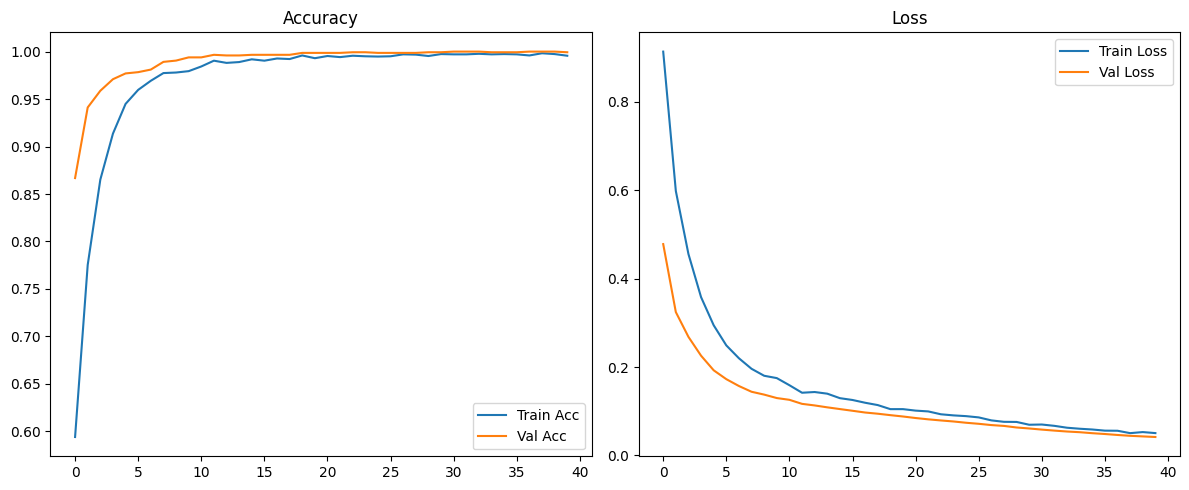

In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# ✅ Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# ✅ Load Data
train_path = "/content/drive/MyDrive/Colab Notebooks/anterior_eye/slit_vgg_train.csv"
test_path = "/content/drive/MyDrive/Colab Notebooks/anterior_eye/slit_vgg_test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# ✅ Split Features and Labels
X_train, y_train = train_df.iloc[:, :-1].values, train_df.iloc[:, -1].values
X_test, y_test = test_df.iloc[:, :-1].values, test_df.iloc[:, -1].values

# ✅ Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ✅ Apply PCA (optional: reduce dimensions to 100 or tune based on variance)
pca = PCA(n_components=100)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

# ✅ Define MLP Model with BatchNorm + Dropout
model = Sequential([
    Dense(64, activation='relu', kernel_regularizer=l2(0.001), input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

# ✅ Compile Model
model.compile(optimizer=Adam(learning_rate=0.0005),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# ✅ Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# ✅ Train Model
history = model.fit(X_train, y_train,
                    validation_split=0.3,
                    epochs=40,
                    batch_size=32,
                    callbacks=[early_stop],
                    verbose=1)

# ✅ Save Model
model.save('/content/drive/MyDrive/Colab Notebooks/anterior_eye/mlp_resnet4_model_revised.h5')

# ✅ Evaluate
loss, acc = model.evaluate(X_test, y_test)
print(f"🎯 Test Accuracy: {acc * 100:.2f}%")

# ✅ Plot Curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()


39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

📈 ROC AUC Score: 0.9697


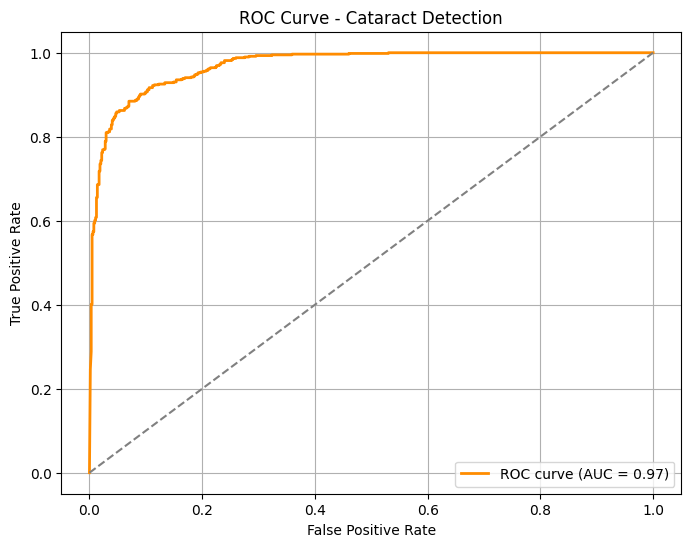

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
from tensorflow.keras.models import load_model
from sklearn.decomposition import PCA # Import PCA
from sklearn.preprocessing import StandardScaler # Import StandardScaler


# ---- Load test data ----
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/anterior_eye/slit_vgg_test.csv")
mlp_model = load_model("/content/drive/MyDrive/Colab Notebooks/anterior_eye/mlp_resnet4_model_revised.h5")

# ---- Convert string labels if needed ----
if df_test['label'].dtype == object:
    df_test['label'] = df_test['label'].map({'cataract': 1, 'normal': 0})

# ---- Separate features and labels ----
X_test = df_test.iloc[:, :-1].values
y_test = df_test.iloc[:, -1].values

# ---- Apply the same preprocessing as during training ----
scaler = StandardScaler() # Create a scaler object
X_test = scaler.fit_transform(X_test) # Scale the test data
pca = PCA(n_components=100) # Create a PCA object with 100 components
X_test = pca.fit_transform(X_test) # Apply PCA to the test data


# ---- Predict probabilities ----
y_pred_proba = mlp_model.predict(X_test)

# ---- Convert probabilities to binary predictions ----
y_pred = (y_pred_proba >= 0.5).astype(int).flatten()

# ---- ROC Curve and AUC ----
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n📈 ROC AUC Score: {auc:.4f}")

# ---- Plot ROC Curve ----
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Cataract Detection")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [3]:
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA # Import PCA
from sklearn.preprocessing import StandardScaler # Import StandardScaler

# ---- Load test features from CSV ----
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/anterior_eye/slit_vgg_test.csv")

# ---- Load trained MLP model correctly ----
mlp_model = load_model("/content/drive/MyDrive/Colab Notebooks/anterior_eye/mlp_resnet4_model_revised.h5")

# ✅ Check if labels need mapping before applying
# If labels are already 0 and 1, this step is skipped.
if df_test['label'].dtype == object:  # If labels are strings (like 'cataract', 'normal')
    df_test['label'] = df_test['label'].map({'cataract': 1, 'normal': 0})

# ---- Split features and labels ----
X_test = df_test.iloc[:, :-1].values  # Features
y_test = df_test.iloc[:, -1].values   # Labels

# ---- Apply the same preprocessing as during training ----
scaler = StandardScaler() # Create a scaler object
X_test = scaler.fit_transform(X_test) # Scale the test data
pca = PCA(n_components=100) # Create a PCA object with 100 components
X_test = pca.fit_transform(X_test) # Apply PCA to the test data

# ---- Predict test set ----
y_pred = mlp_model.predict(X_test)

# ---- Convert probability predictions to binary (0 or 1) ----
y_pred = (y_pred >= 0.5).astype(int)  # Threshold at 0.5
# ---- Flatten predictions ----
y_pred = y_pred.flatten().astype(int)

# ---- Evaluate performance ----
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Test Accuracy: {accuracy * 100:.2f}%")

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Normal", "Cataract"]))

print("\n🔹 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
🎯 Test Accuracy: 90.99%

📊 Classification Report:
              precision    recall  f1-score   support

      Normal       0.92      0.91      0.91       643
    Cataract       0.90      0.91      0.91       589

    accuracy                           0.91      1232
   macro avg       0.91      0.91      0.91      1232
weighted avg       0.91      0.91      0.91      1232


🔹 Confusion Matrix:
[[585  58]
 [ 53 536]]
